# Multi-panel figures and compound figure (Solution)

Muc tieu:
- Biet khi nao dung multi-panel (small multiples) de so sanh cong bang.
- Biet tao compound figure co 1 thong diep chinh + panel phu tro.
- Biet quan ly layout, title, annotation, legend nhat quan.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "owid_co2_subset.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/owid_co2_subset.csv")

root = resolve_repo_root()
sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "owid_co2_subset.csv")
# keep country-level rows with key indicators
df = df.dropna(subset=["co2_per_capita", "gdp", "population"]).copy()
d_recent = df[df["year"] >= 2000].copy()
d_latest = d_recent[d_recent["year"] == d_recent["year"].max()].copy()
d_latest.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,coal_co2,energy_per_capita,gas_co2,methane,nitrous_oxide,oil_co2,primary_energy_consumption,temperature_change_from_ghg,trade_co2
32,Afghanistan,2022,AFG,40578847.0,5.330347e+10,10.170,0.251,3.488,1111.573,0.143,16.076,4.419,6.528,45.106,0.001,NaN
67,Albania,2022,ALB,2827614.0,3.617101e+10,4.498,1.591,0.542,9147.205,0.088,2.431,0.864,2.946,25.865,0.000,1.188
102,Algeria,2022,DZA,45477391.0,5.958201e+11,192.779,4.239,0.758,16145.337,101.379,67.576,8.200,61.610,734.248,0.005,NaN
172,Angola,2022,AGO,35635028.0,1.583462e+11,21.089,0.592,NaN,2713.824,1.927,45.564,17.332,14.887,96.707,0.006,NaN
312,Argentina,2022,ARG,45407904.0,8.549144e+11,183.768,4.047,4.731,22049.938,89.620,115.333,50.296,81.967,1001.241,0.016,0.078


## 1) Multi-panel co cung truc (fair comparison)

Case: so sanh phan bo `lifeExp` theo continent.
Dung cung x/y limits de tranh gay ao giac khac biet do scale.

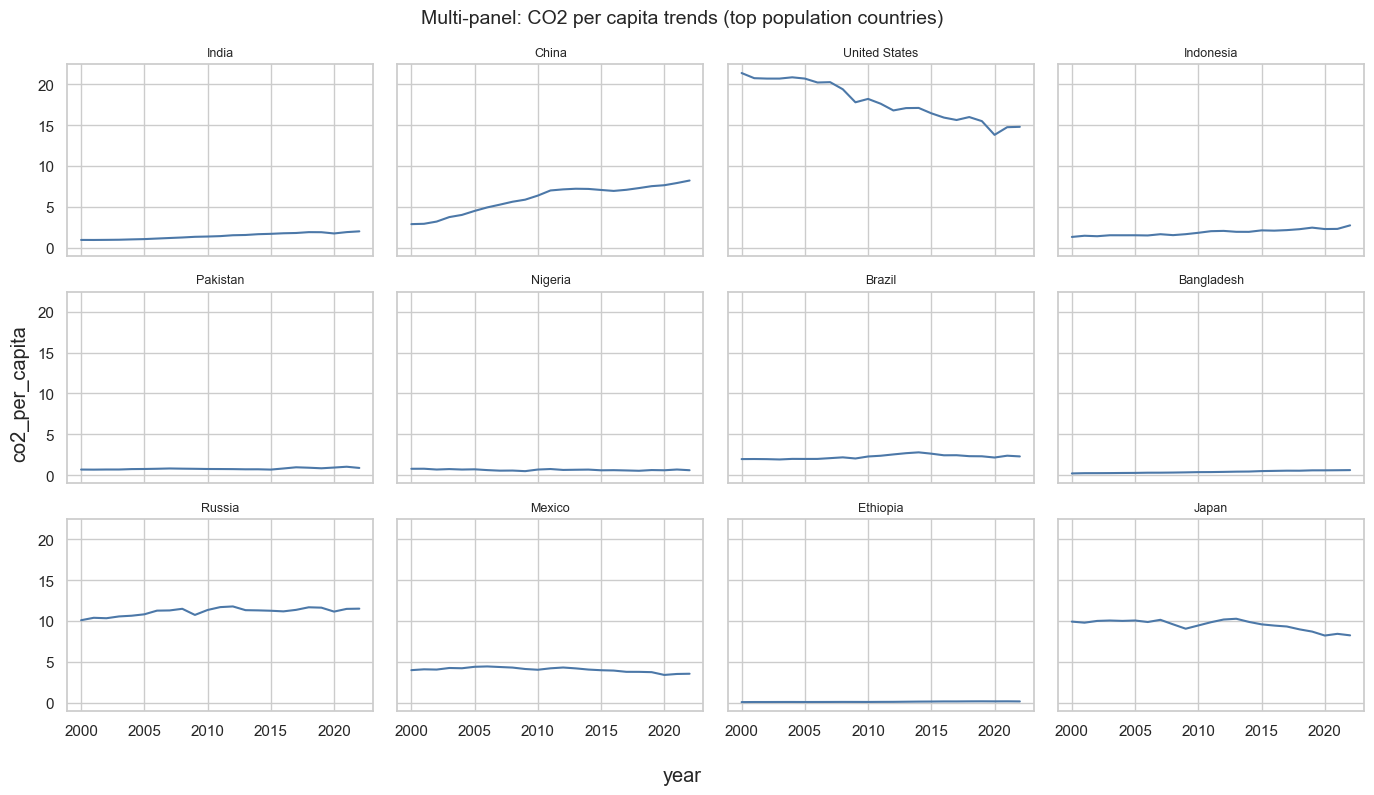

In [2]:
top = d_latest.groupby('country', as_index=False)['population'].mean().nlargest(12, 'population')['country']
sub = d_latest[d_latest['country'].isin(top)].copy()

fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()
for ax, c in zip(axes, top):
    x = d_recent[d_recent['country']==c]['year']
    y = d_recent[d_recent['country']==c]['co2_per_capita']
    ax.plot(x, y, color='#4C78A8', linewidth=1.5)
    ax.set_title(c, fontsize=9)
for ax in axes[len(top):]:
    ax.axis('off')
fig.suptitle('Multi-panel: CO2 per capita trends (top population countries)', fontsize=14)
fig.supxlabel('year')
fig.supylabel('co2_per_capita')
plt.tight_layout(); plt.show()

## 2) Multi-panel voi y nghia so sanh ro (trend theo thoi gian)

Case: trend `lifeExp` theo nam, tach panel theo continent.

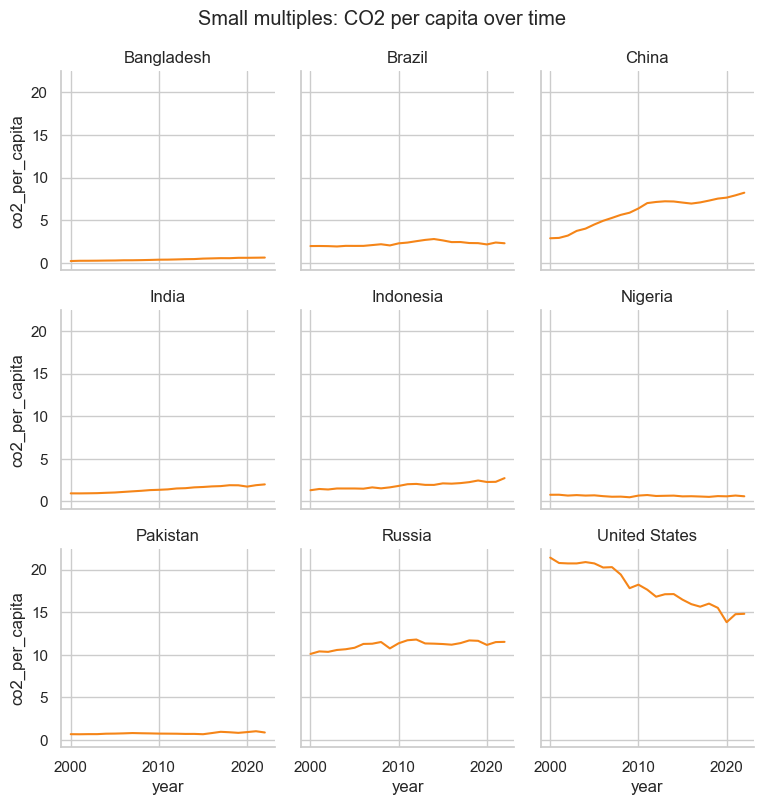

In [3]:
top = d_latest.groupby('country', as_index=False)['population'].mean().nlargest(9, 'population')['country']
trend = d_recent[d_recent['country'].isin(top)][['country','year','co2_per_capita']].dropna()

g = sns.FacetGrid(trend, col='country', col_wrap=3, height=2.6, sharex=True, sharey=True)
g.map_dataframe(sns.lineplot, x='year', y='co2_per_capita', color='#F58518')
g.set_titles(col_template='{col_name}')
g.fig.suptitle('Small multiples: CO2 per capita over time', y=1.03)
plt.show()

## 3) Compound figure (mot thong diep + nhieu panel)

Thong diep: "GDP cao thuong di cung life expectancy cao, nhung phan bo theo khu vuc rat khac nhau".

Cau truc figure:
- Panel A (lon): scatter tong quan GDP vs lifeExp.
- Panel B: bar mean lifeExp theo continent.
- Panel C: boxplot lifeExp theo continent.

/var/folders/v6/3bggzf691gn6h26h5hxxgq400000gp/T/ipykernel_82278/1923875613.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg, x='co2_per_capita', y='country', palette='viridis', ax=axB)
/var/folders/v6/3bggzf691gn6h26h5hxxgq400000gp/T/ipykernel_82278/1923875613.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


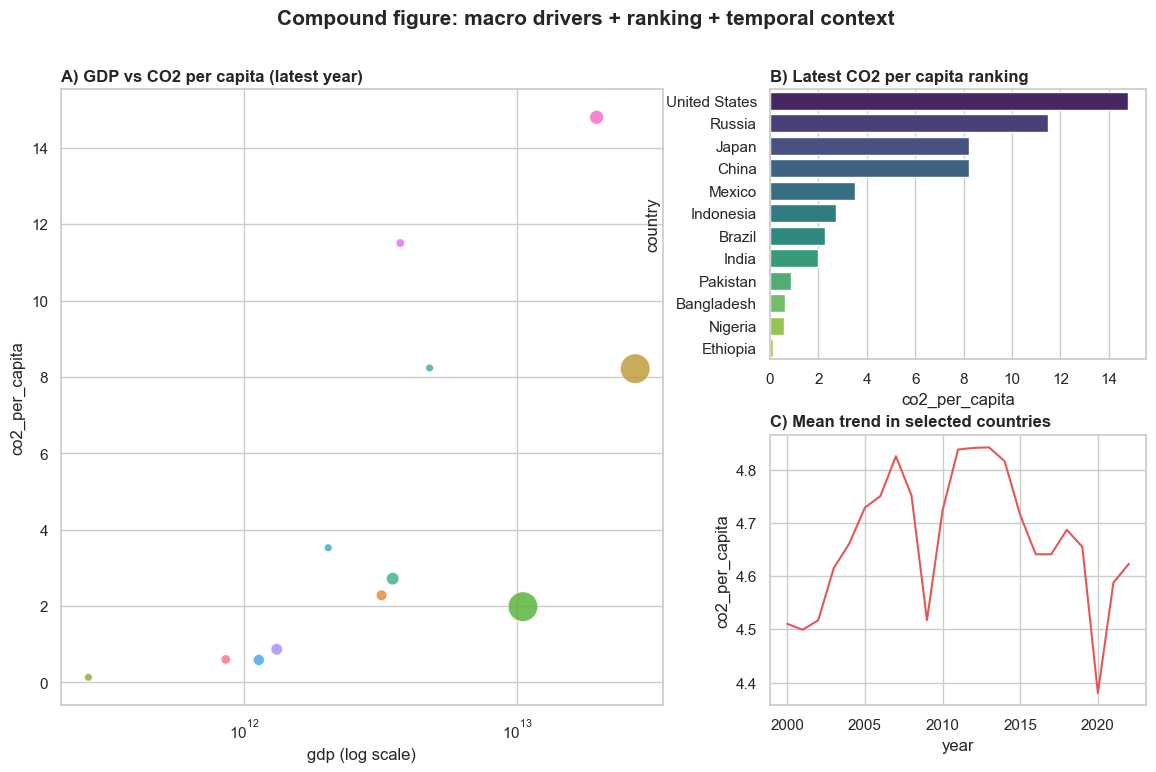

In [4]:
import matplotlib.gridspec as gridspec

top = d_latest.groupby('country', as_index=False)['population'].mean().nlargest(12, 'population')['country']
sub_latest = d_latest[d_latest['country'].isin(top)].copy()
sub_trend = d_recent[d_recent['country'].isin(top)].copy()

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.6, 1], height_ratios=[1, 1], hspace=0.28, wspace=0.22)

axA = fig.add_subplot(gs[:, 0])
sns.scatterplot(data=sub_latest, x='gdp', y='co2_per_capita', size='population', hue='country', sizes=(30, 450), alpha=0.8, ax=axA, legend=False)
axA.set_xscale('log')
axA.set_title('A) GDP vs CO2 per capita (latest year)', loc='left', fontweight='bold')
axA.set_xlabel('gdp (log scale)')
axA.set_ylabel('co2_per_capita')

axB = fig.add_subplot(gs[0, 1])
agg = sub_latest.groupby('country', as_index=False)['co2_per_capita'].mean().sort_values('co2_per_capita', ascending=False)
sns.barplot(data=agg, x='co2_per_capita', y='country', palette='viridis', ax=axB)
axB.set_title('B) Latest CO2 per capita ranking', loc='left', fontweight='bold')

axC = fig.add_subplot(gs[1, 1])
world = sub_trend.groupby('year', as_index=False)['co2_per_capita'].mean()
sns.lineplot(data=world, x='year', y='co2_per_capita', color='#E45756', ax=axC)
axC.set_title('C) Mean trend in selected countries', loc='left', fontweight='bold')

fig.suptitle('Compound figure: macro drivers + ranking + temporal context', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(); plt.show()

## 4) Design checklist cho compound figure

- Panel chinh dat ben trai/tren trai, panel phu dat ben phai/duoi.
- Tieu de panel co nhan A/B/C va cung phong cach.
- Truc, don vi, scale nhat quan de doc chinh xac.
- Legend khong lap lai khong can thiet.
- Chu thich ngan gon de noi thong diep, khong de nguoi doc tu doan.

## Reflection

1. Khi nao nen tach thanh multi-panel thay vi ve chung 1 chart?
2. Compound figure cua ban co panel nao la "main evidence"? Vi sao?
3. Neu phai dua vao 1 slide cho manager, ban giu lai panel nao va bo panel nao?